# 실습] Cifar10 + DeepCNN

- GoogleDriver 마운트
- GPU 사용을 권장

- 샘플파일 다운로드
  - https://www.dropbox.com/scl/fi/swnxia7a6u9lhb51mryth/cifar10.zip?rlkey=1hb32xg9ondhkhfgthrksg4na&st=wgomiqv3&dl=1


# 🟦 Cifar10 데이터셋

![](https://static.wikidocs.net/images/page/266018/%EC%8A%A4%ED%81%AC%EB%A6%B0%EC%83%B7_2024-11-08_004635.png)


**CIFAR-10 데이터셋**은 **머신러닝과 딥러닝에서 이미지 분류(Image Classification)** 문제를 실험하고 연구할 때 가장 널리 사용되는 **표준 벤치마크 데이터셋** 중 하나.

---

### 🧠 기본 정보

| 항목          | 내용                                                               |
| ----------- | ---------------------------------------------------------------- |
| **이름**      | CIFAR-10 (Canadian Institute for Advanced Research 10 classes)   |
| **제공처**     | 캐나다 고등연구소(CIFAR), 토론토대학교의 Alex Krizhevsky, Geoffrey Hinton 등이 제작 |
| **데이터 크기**  | 총 60,000장의 컬러 이미지                                                |
| **이미지 크기**  | 32 × 32 픽셀, RGB(3채널)                                             |
| **클래스 수**   | 10개 (서로 겹치지 않음)                                                  |
| **훈련 데이터**  | 50,000장                                                          |
| **테스트 데이터** | 10,000장                                                          |

---

### 🏷️ 클래스(레이블)

CIFAR-10에는 총 **10개의 클래스**가 있으며, 각각은 서로 다른 물체 범주.

| 클래스 이름     | 설명            |
| ---------- | ------------- |
| airplane   | 비행기           |
| automobile | 자동차 (트럭 제외)   |
| bird       | 새             |
| cat        | 고양이           |
| deer       | 사슴            |
| dog        | 개             |
| frog       | 개구리           |
| horse      | 말             |
| ship       | 배             |
| truck      | 트럭 (자동차와 구분됨) |

---

### 🧩 데이터 구조

* 각 이미지는 32×32 크기의 RGB 이미지 → shape = `(32, 32, 3)`
* 각 클래스당 6,000장씩 균등하게 분포

  * 훈련: 5,000장/클래스
  * 테스트: 1,000장/클래스

---

---

### 🚀 활용 예시

* **CNN(Convolutional Neural Network)** 구조 실험
  → 예: LeNet, AlexNet, VGG, ResNet 등의 구조 실험용
* **데이터 증강(Data Augmentation)** 및 정규화 실험
* **전이학습(Transfer Learning)** 기초 실습
* **GAN, 오토인코더 등 생성 모델** 학습 실험에도 자주 사용

---

### 📊 CIFAR-10의 변형 버전

| 이름             | 특징                              |
| -------------- | ------------------------------- |
| **CIFAR-100**  | 100개의 클래스, 각 600장씩 (보다 세분화된 버전) |
| **CIFAR-10H**  | 사람들의 주관적 확률 분포(불확실성) 포함         |
| **CIFAR-10.1** | 새로운 테스트 세트로 일반화 성능 측정용          |



# 1.import
- 필요한 import 수행

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from glob import glob

import tensorflow as tf
import keras
from keras import datasets, layers, models

from sklearn.model_selection import train_test_split

import random
def set_seed(seed = 42):
  tf.keras.utils.set_random_seed(seed)
  tf.config.experimental.enable_op_determinism()

set_seed(42)

# 2.경로설정
- 필요한 경로변수를 설정하세요
- model_path= 변수에 모델을 저장할 경로를 설정합니다.
- 모델파일명: `best-cifar10-deepcnn.keras`

In [2]:
base_path = r'/content/drive/MyDrive/K-digita_국비/DeepLearning/proj_cifar10'
# 학습된 모델 저장할 경로 지정
model_path = os.path.join(base_path, 'out', 'best-cifar10-deepcnn.keras')

# 3.데이터 준비

## 3.1.데이터셋 로드
- 데이터셋 로드 하고 train, test 데이터 와 타겟의 shape 를 확인하세요

In [3]:
# 1. 데이터셋 로드 하고 train, test 데이터 와 타겟의 shape 를 확인하세요
(train_input, train_target), (test_input, test_target) =\
   datasets.cifar10.load_data()

# 로딩한 train, test 데이터셋의 shape 출력
print(train_input.shape)
print(train_target.shape)
print(test_input.shape)
print(test_target.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [4]:
# train 타겟의 unique 한 값들과 개수를 확인하세요
unique_labels, counts = np.unique(train_target, return_counts=True)

print(unique_labels)
print(counts)

[0 1 2 3 4 5 6 7 8 9]
[5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]


In [5]:
# test 타겟의 unique 한 값들과 개수를 확인하세요
unique_labels, counts = np.unique(test_target, return_counts=True)

print(unique_labels)
print(counts)

[0 1 2 3 4 5 6 7 8 9]
[1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


## 3.2.클래스 이름 설정
- 클래스 이름 설정 (데이터셋 확인용)

In [6]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

## 3.3.첫 64개의 시각화
- 첫 64개 샘플을 8x8 figure 로 시각화 합니다.
-  각 이미지와 더불어, title 에 target값 과 클래스 이름을 출력합니다.


- 예시]

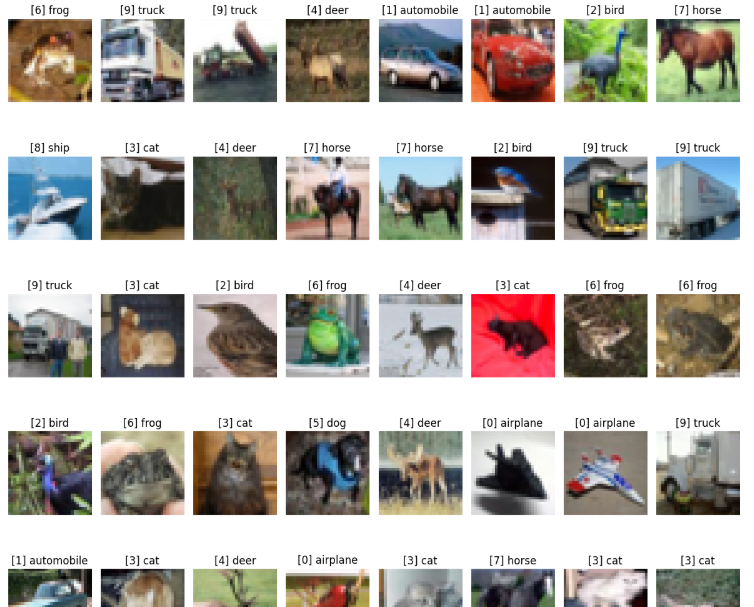

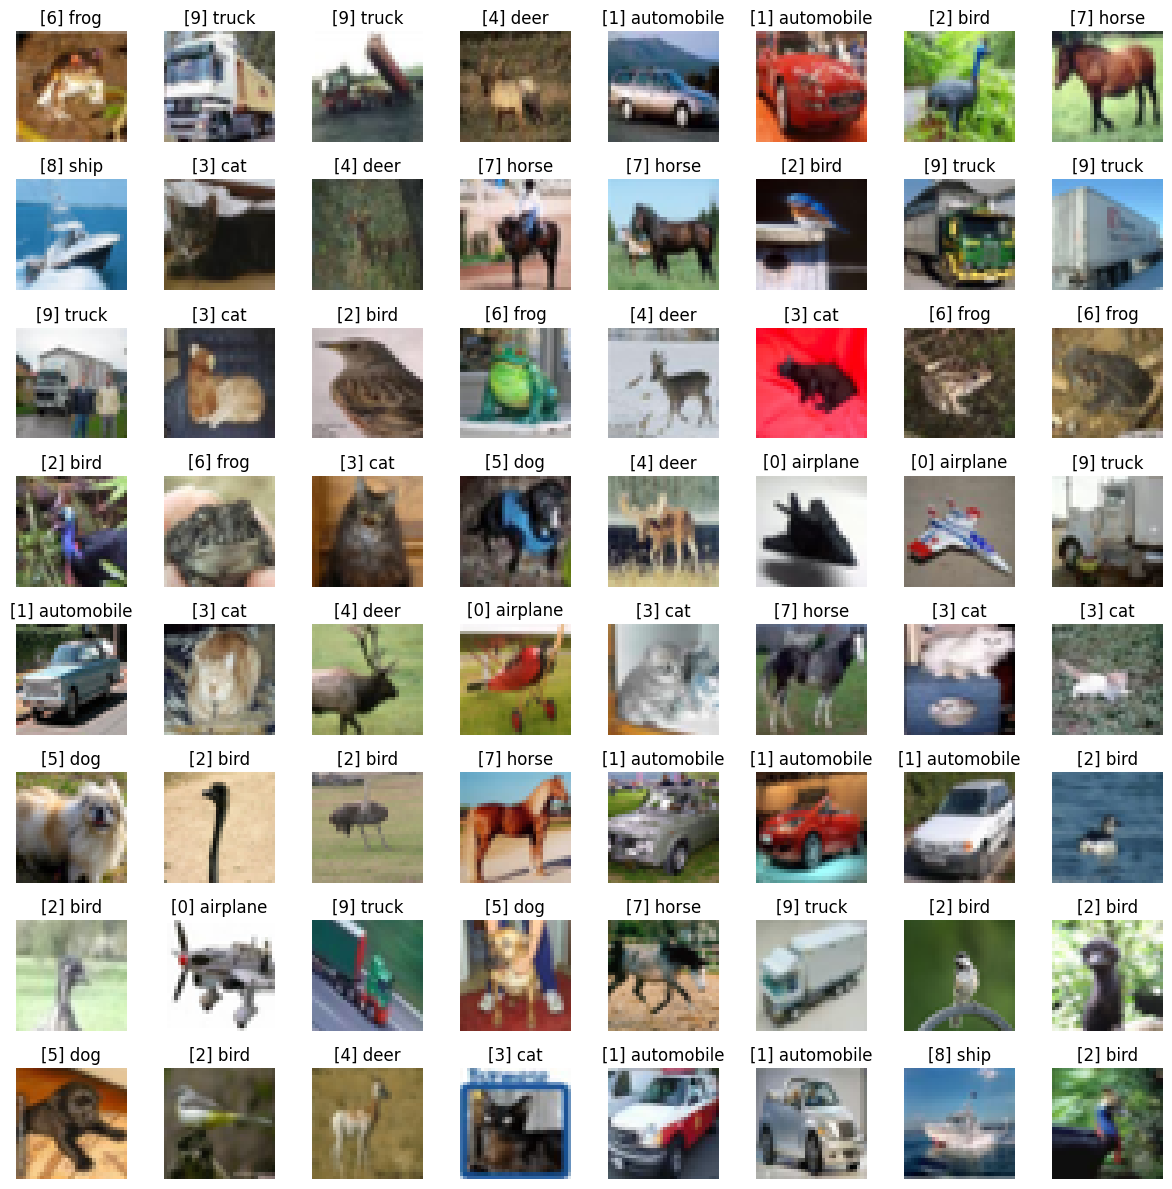

In [7]:
plt.figure(figsize=(12,12))

for i in range(64):
  plt.subplot(8, 8, i + 1)
  plt.imshow(train_input[i])

  label = train_target[i][0]
  plt.title(f'[{label}] {class_names[label]}')

  plt.axis('off')


plt.tight_layout()
plt.show()



## 3.4.정규화
- 픽셀 값 정규화 (0 ~ 255 사이의 값을 0 ~
1 사이로 스케일링)

In [8]:
# 2. 픽셀 값 정규화 (0~255 사이의 값을 0~1 사이로 변경)
train_scaled = train_input/255.0
test_scaled = test_input/255.0


# train, test 데이터의 스케일된 결과의 각각 최대값 최소값 출력 확인
print('train_scaled : ', train_input.min(), train_input.max())
print('test_scaled : ', test_input.min(), test_input.max())

train_scaled :  0 255
test_scaled :  0 255


## 3.5.검증세트 분리
- train 데이터셋에서 20% 를 검증(validation) 용 데이터 셋으로 분리합니다.

In [9]:
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target,test_size=0.2, random_state=42)


# 분리후 train, validataion, test 데이터셋의 shape 출력
print(train_scaled.shape)
print(train_target.shape)
print(val_scaled.shape)
print(val_target.shape)
print(test_input.shape)
print(test_target.shape)


(40000, 32, 32, 3)
(40000, 1)
(10000, 32, 32, 3)
(10000, 1)
(10000, 32, 32, 3)
(10000, 1)


# 2.모델정의

- 아래와 같은 layer 로 구성된 CNN 모델 작성하기
- 입출력 shape 주목!
<img src="https://www.dropbox.com/scl/fi/k6haahp1hywzz7fvf8k6w/cifar10-deepcnn.png?rlkey=t9vnfvedhnrmagndcgaeyloze&st=c635tqmi&dl=1" width="400" height='auto'>

## 2.1.모델 정의
- `model` 변수에 정의
- summary() 출력

In [10]:
set_seed(42)

# 2. 모델 구성 (Dropout 추가)
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(filters=32, kernel_size=(3,3), activation = 'relu', padding='same'),

    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='valid'),

    layers.MaxPooling2D(2),

    layers.Dropout(rate=0.25),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='valid'),

    layers.MaxPooling2D(2),

    layers.Dropout(rate=0.25),

    layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'),

    layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='valid'),

    layers.MaxPooling2D(2),

    layers.Dropout(rate=0.25),

    layers.Flatten(),

    # 특징을 조합하는 dense 그래서 activation = 'relu'를 사용함
    layers.Dense(512, activation='relu'),

    layers.Dropout(rate=0.25),

    layers.Dense(10, activation='softmax')

])

# model.summary() 값 출력
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 554,794 (2.12 MB)

 Trainable params: 554,794 (2.12 MB)

 Non-trainable params: 0 (0.00 B)

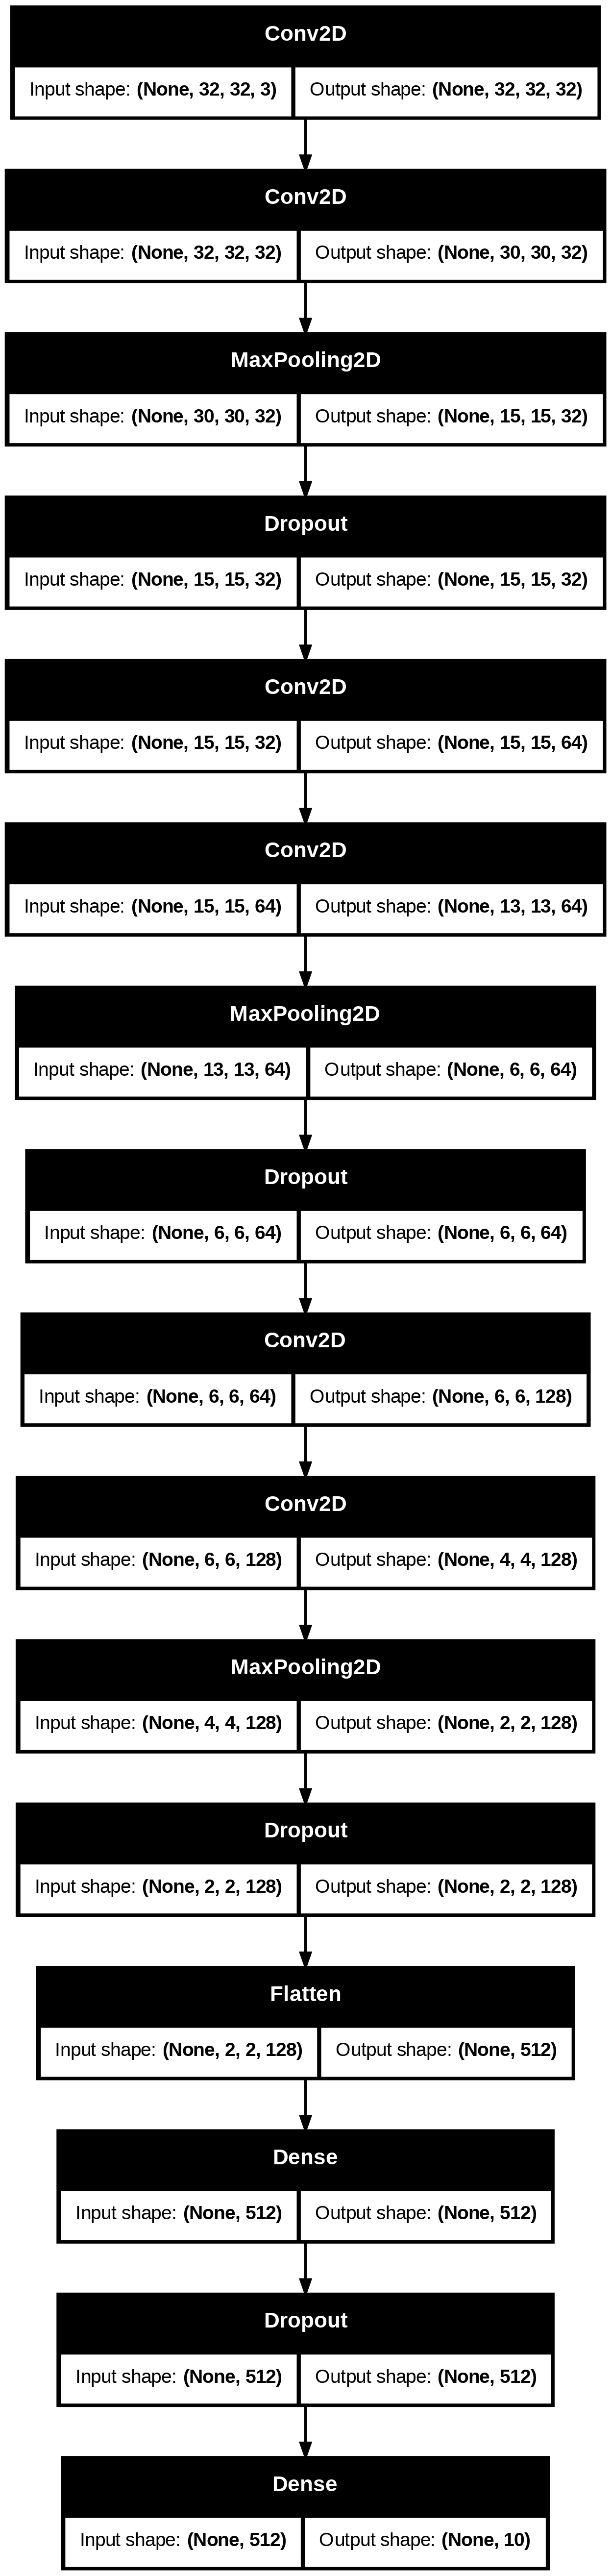

In [11]:
# 모델 레이어 시각화 하기
keras.utils.plot_model(model, show_shapes=True)


## 2.2.각 레이어의 파라미터 개수 계산하기
- 아래 셀에 주석으로 각 레이어별로 파라미터 개수를 계산하고 설명해보세요
- 파라미터가 없는 레이어는 생략해도 됩니다

In [12]:
"""

model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    출력 shape -> (32, 32, 3)
    모델 파라미터 개수 ->  0

    layers.Conv2D(filters=32, kernel_size=(3,3), activation = 'relu', padding='same'),

    출력 shape -> (32, 32, 32)
    모델 파라미터 개수 -> (3 * 3 * 3 + 1) * 32 = 896 개

    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='valid'),

    출력 shape -> (30, 30, 32)
    모델 파라미터 개수 -> (3 * 3 * 32 + 1) * 32 = 9,248 개

    layers.MaxPooling2D(2),

    출력 shape -> (15, 15, 32)
    모델 파라미터 개수 -> 0

    layers.Dropout(rate=0.25),

    출력 shape -> (15, 15, 32)
    모델 파라미터 개수 -> 0


    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'),

    출력 shape -> (15, 15 ,64)
    모델 파라미터 개수 -> (3 * 3 * 32 + 1) * 64 = 18,496 개

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='valid'),

    출력 shape -> (13, 13, 64)
    모델 파라미터 개수 -> (3 × 3 × 64 + 1) × 64 = 36,928 개

    layers.MaxPooling2D(2),

    출력 shape -> (6, 6, 64)
    모델 파라미터 개수 -> 0

    layers.Dropout(rate=0.25),

    출력 shape -> (6, 6, 64)
    모델 파라미터 개수 -> 0

    layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'),

    출력 shape -> ( 6, 6, 128)
    모델 파라미터 개수 -> (3 × 3 × 64 + 1) × 128 = 73,856 개

    layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='valid'),

    출력 shape -> (4, 4, 128)
    모델 파라미터 개수 -> (3 × 3 × 128 + 1) × 128 = 147,584

    layers.MaxPooling2D(2),

    출력 shape -> (2, 2, 128)
    모델 파라미터 개수 -> 0

    layers.Dropout(rate=0.25),

    출력 shape -> (2, 2, 128)
    모델 파라미터 개수 -> 0

    layers.Flatten(),

    출력 shape -> (512)
    모델 파라미터 개수 -> 0

    layers.Dense(512, activation='relu'),

    출력 shape -> (512)
    모델 파라미터 개수 -> (512 + 1) × 512 = 262,656

    layers.Dropout(rate=0.25),]

    출력 shape -> (512)
    모델 파라미터 개수 -> 0

    layers.Dense(10, activation='softmax')

    출력 shape -> (10)
    모델 파라미터 개수 -> (512 + 1) × 10 = 5,130 개

])


"""
None

# 3.모델 컴파일
- optimizer 는 'Adam' 사용
- metric 은 'accuracy' 사용

In [13]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 4.콜백 정의
- ModelCheckpoint 정의
  - model_path 에 학습 모델 저장
  - 가장 학습이 잘된 모델만 저장
- EarlyStopping 정의
  - patience : 3
  - 학습 종료후, 최적의 weight 값 복원하기

In [14]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(filepath = model_path, save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)


# 5.훈련
- epochs = 100 으로 훈련
- validation 데이터 제공
- fit() 의 결과로 History 객체 받기

In [15]:
# Colab GPU : 약 4분

history = model.fit(train_scaled, train_target, epochs=100, validation_data=(val_scaled, val_target), callbacks = [checkpoint_cb, early_stopping_cb])


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.2767 - loss: 1.9050 - val_accuracy: 0.5184 - val_loss: 1.3003
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5124 - loss: 1.3450 - val_accuracy: 0.5979 - val_loss: 1.1223
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5761 - loss: 1.1833 - val_accuracy: 0.6493 - val_loss: 0.9976
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.6168 - loss: 1.0722 - val_accuracy: 0.6698 - val_loss: 0.9270
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.6534 - loss: 0.9799 - val_accuracy: 0.6958 - val_loss: 0.8616
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.6681 - loss: 0.9317 - val_accuracy: 0.6930 - val_loss: 0.8564
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.6911 - loss: 0.8856 - val_accuracy: 0.7102 - val_loss: 0.8106
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 

# 6.손실곡선 (loss curve) 작성
- train loss 와 validation loss 곡석 시각화
- ✅손실 곡선 작성후 평가결과를 주석으로 남겨주세요

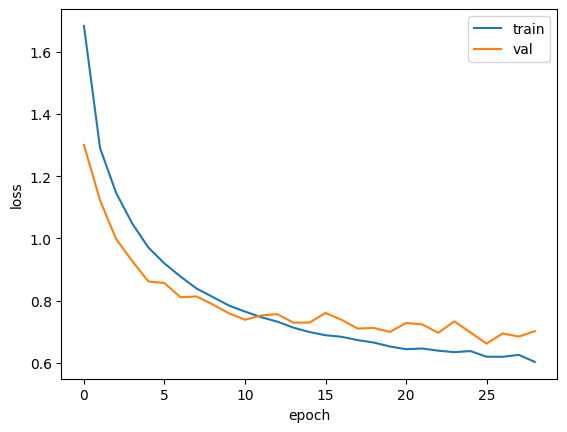

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [16]:
'''
위 그래프를 보면 loss값이 epochs 가 증가 할 수록 감소하기 시작함을 볼 수 있다.
epochs = 29에서 멈춘거로 보아, epochs - 26값이 가장 최고의 학습 결과라고 판단 할 수 있다.
'''

# 7.성능평가
- 검증 점수와 테스트 점수 확인
- ✅점수 확인후 결과에 대한 주석을 남기세요

In [18]:
# 검증 점수
model.evaluate(val_scaled, val_target)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7716 - loss: 0.6549


[0.6616616249084473, 0.7710999846458435]

In [19]:
# 테스트 점수
model.evaluate(test_input, test_target)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4733 - loss: 130.3150


[130.82034301757812, 0.4749999940395355]

In [ ]:
'''
검증 정확도는 77%
테스트 정확도를 47%로 모델이 검증 데이터에는 꽤 적합하나
보지 못한 데이터에 있어서는 꽤나 낮은 성능을 보여준
'''

# 8.예측하기
- 첫번째 샘플 이미지를 예측해보세요

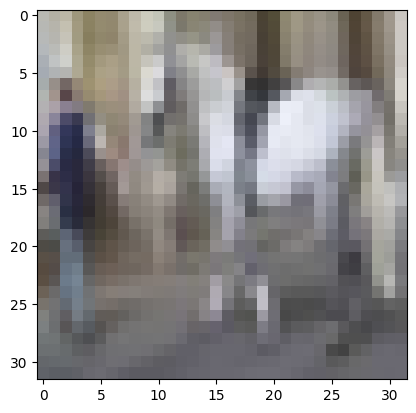

In [23]:
# 우선 첫번째 샘플 이미지부터 확인!
plt.imshow(val_scaled[0], cmap='gray_r')
plt.show()

In [24]:
# predict() 사용. 위 샘플의 예측값 확인

pred = model.predict(val_scaled[0:1])
print(pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
[[6.8717700e-04 3.8838555e-04 2.3127021e-02 6.2556756e-01 1.1667996e-01
  1.5241154e-01 1.3474735e-03 7.4310295e-02 1.0763315e-03 4.4042426e-03]]


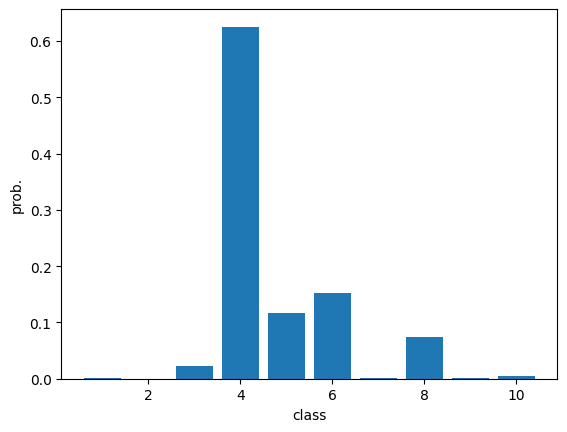

In [25]:
plt.bar(range(1, 11), pred[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()

In [27]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
class_names[np.argmax(pred)]

'cat'

# 9.모델 저장
- `model_path` 경로로 학습된 모델을 저장합니다

In [28]:
model.save(model_path)

# 10.모델 불러오기

In [30]:
model = keras.models.load_model(model_path)

In [31]:
# 모델 불러온뒤 validatiion 데이터셋으로 점수 확인.
model.evaluate(val_scaled, val_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7716 - loss: 0.6549


[0.6616616249084473, 0.7710999846458435]

# 11.실제 데이터 1개 예측하기

## 11.1.이미지 한장을 예측해보세요
- 배포된 샘플 이미지 한장을 사용하여 예측해보세요

In [32]:
img_base_path = r'/content/drive/MyDrive/K-digita_국비/DeepLearning/Dataset/cifar10테스트용'

In [33]:
# 이미지 경로들을 list 로 불러오기
img_paths = glob(os.path.join(img_base_path, 'img_*.*'))

In [36]:
from PIL import Image
import  PIL.ImageOps as ops

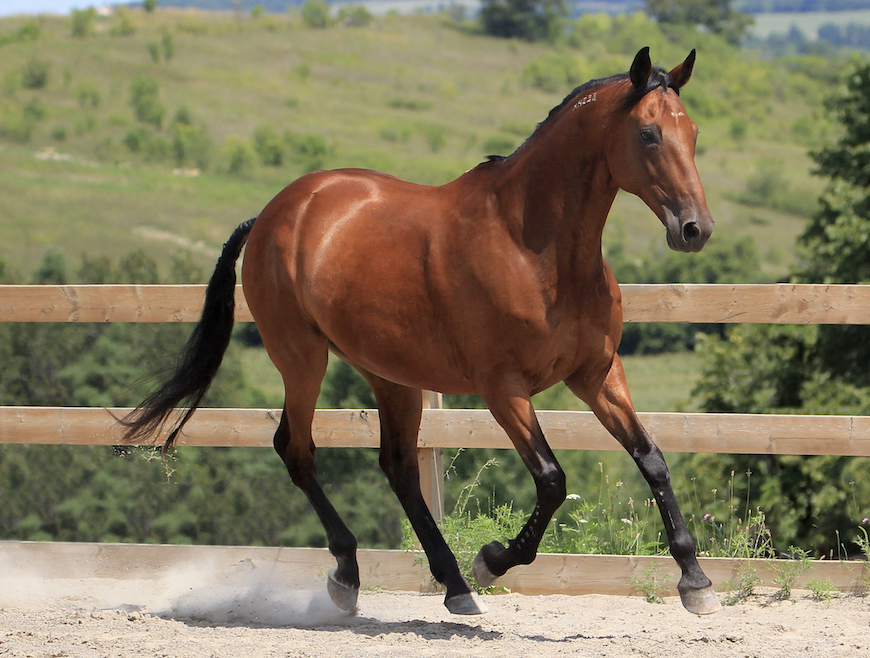

In [58]:
# 첫번째 이미지 예측하기

file_path = img_paths[0]
img = Image.open(file_path)
img

## 11.2.위 예측동작하는 함수를 만들어 보세요

In [47]:
# 함수로 만들어 보자.
# 입력: 이미지 파일 경로 (str)
# 출력: 예측 클래스 (str)
import numpy as np
from PIL import Image

def predict(file_path):
    img = Image.open(file_path).convert('RGB')
    img = img.resize((32, 32))
    img_array = np.array(img)
    img_scaled = img_array / 255.0
    img_scaled = img_scaled.reshape(1, 32, 32, 3)
    preds = model.predict(img_scaled)
    return class_names[np.argmax(preds)]


In [48]:
# 동작 확인
for img_path in img_paths:
  print(img_path, '->', predict(img_path))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
/content/drive/MyDrive/K-digita_국비/DeepLearning/Dataset/cifar10테스트용/img_horse.png -> horse
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
/content/drive/MyDrive/K-digita_국비/DeepLearning/Dataset/cifar10테스트용/img_dog.jpg -> deer
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
/content/drive/MyDrive/K-digita_국비/DeepLearning/Dataset/cifar10테스트용/img_automobile.jpg -> automobile
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
/content/drive/MyDrive/K-digita_국비/DeepLearning/Dataset/cifar10테스트용/img_frog.png -> frog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
/content/drive/MyDrive/K-digita_국비/DeepLearning/Dataset/cifar10테스트용/img_cat.jpg -> cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
/content/drive/MyDrive/K-digita_국비/DeepLearning/Dataset/cifar10테스트용/img_bird.jpg -> bird
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
/content/drive/MyDrive/K-digita_국비/DeepLearning/Dataset/cifar10테스트용/img_truck.jpeg -> truck
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
/

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


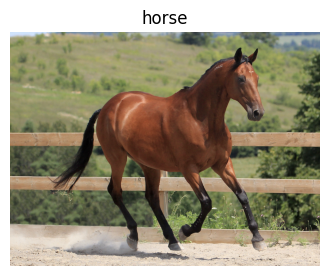

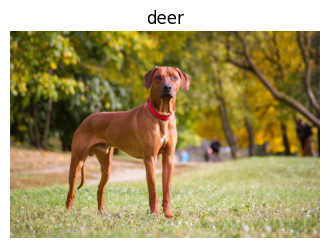

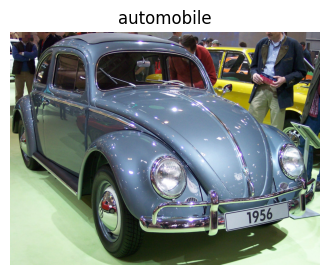

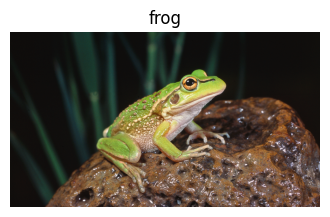

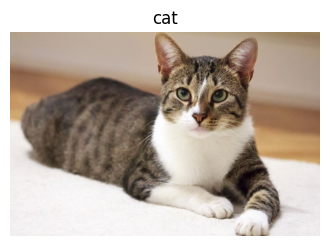

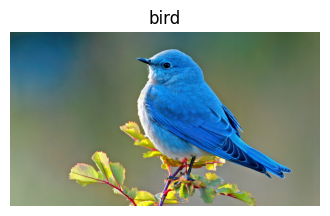

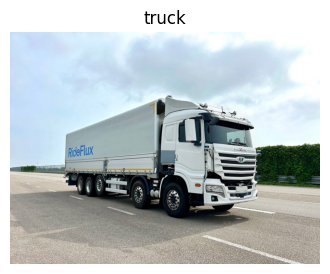

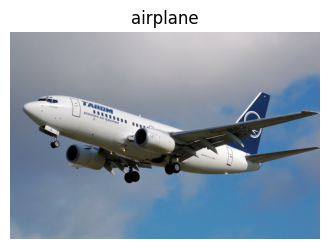

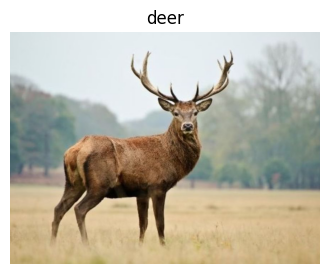

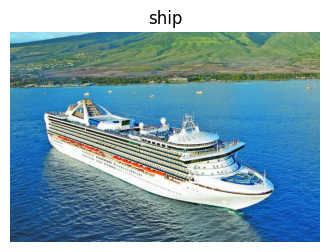

In [49]:
# 동작확인
for img_path in img_paths:
  fig, ax = plt.subplots(1, 1, figsize=(4, 4))
  ax.axis('off')
  pred = predict(img_path)
  ax.set_title(pred)  # colab 에선 한글 폰트 설치해야되서리 pass
  arr = plt.imread(img_path)
  plt.imshow(arr)

# 12.여러 데이터 예측 하기
- 명심: predict() 도 feature vector 로 받는다
- ✅이 함수를 사용하여 웹 애플리케이션에 적용할겁니다

In [50]:
# 입력: List[str] 파일경로들의 리스트
# 출력: List[str] 예측 class name 들의 리스트
def predict_images(img_paths):
    imgs = []

    for path in img_paths:
        img = Image.open(path).convert('RGB')
        img = img.resize((32, 32))
        img_array = np.array(img)
        img_array = img_array / 255.0
        imgs.append(img_array)

    batch_imgs = np.array(imgs)
    preds = model.predict(batch_imgs)
    preds_classes = [class_names[np.argmax(p)] for p in preds]

    return preds_classes

In [59]:
# 동작확인
predict_images(img_paths[:4])
# ['horse', 'dog', 'automobile', 'frog']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


['horse', 'deer', 'automobile', 'frog']